**Настройка окружения**

In [2]:
# Импорты
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

import sys
from pathlib import Path


# Поиск корня
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Корень проекта добавлен в sys.path: {project_root}")
print('Окружение настроено')

Корень проекта добавлен в sys.path: /home/mojusei/Data/ML/fake-news-detector
Окружение настроено


**Загрузка и осмотр данных**

In [3]:
from src.data import load_data


# Загрузка данных
news = load_data()

# Предварительный просмотр данных
print(f"Размер датасета: {news.shape}")
print(f"Пример данных:")
print(news.head())

Загрузка датасета...
Датасет успешно загружен
Размер датасета: (6335, 4)
Пример данных:
   Unnamed: 0                                              title  \
0        8476                       You Can Smell Hillary’s Fear   
1       10294  Watch The Exact Moment Paul Ryan Committed Pol...   
2        3608        Kerry to go to Paris in gesture of sympathy   
3       10142  Bernie supporters on Twitter erupt in anger ag...   
4         875   The Battle of New York: Why This Primary Matters   

                                                text label  
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE  
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE  
2  U.S. Secretary of State John F. Kerry said Mon...  REAL  
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE  
4  It's primary day in New York and front-runners...  REAL  


Распределение классов:
label
REAL    3171
FAKE    3164
Name: count, dtype: int64


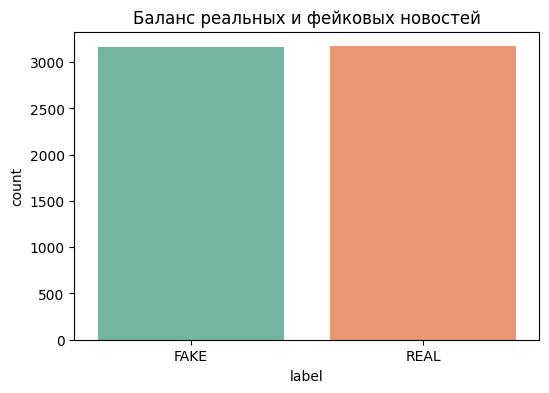

In [4]:
# Распределение меток
print("Распределение классов:")
print(news['label'].value_counts())

# Визуализация баланса классов
plt.figure(figsize=(6, 4))
sns.countplot(news, x='label', hue='label', palette='Set2')
plt.title('Баланс реальных и фейковых новостей')
plt.show()

**Предобработка**

In [5]:
from src.data import clean_data


# Преобразование меткок в числовой формат и удаление пропусков (если есть)
news = clean_data(news)
print(news.head())

   Unnamed: 0                                              title  \
0        8476                       You Can Smell Hillary’s Fear   
1       10294  Watch The Exact Moment Paul Ryan Committed Pol...   
2        3608        Kerry to go to Paris in gesture of sympathy   
3       10142  Bernie supporters on Twitter erupt in anger ag...   
4         875   The Battle of New York: Why This Primary Matters   

                                                text  label  
0  Daniel Greenfield, a Shillman Journalism Fello...      0  
1  Google Pinterest Digg Linkedin Reddit Stumbleu...      0  
2  U.S. Secretary of State John F. Kerry said Mon...      1  
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...      0  
4  It's primary day in New York and front-runners...      1  


In [6]:
from src.data import get_train_test_split


# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = get_train_test_split(news, test_size=0.2, random_state=42)

print(f"Количество записей в обучающей выборке: {X_train.shape[0]}")
print(f"Количество записей в тестовой выборке: {X_test.shape[0]}")

Количество записей в обучающей выборке: 5068
Количество записей в тестовой выборке: 1267


**Обучение модели**

In [7]:
from src.model import FakeNewsClassifier


model = FakeNewsClassifier()
model.train(X_train, y_train)

print('Модель обучена')

Модель обучена


**Предсказание и оценка точности модели**

In [8]:
# Предсказание
y_pred = model.predict(X_test)

# Точность
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели: {accuracy:.2%}")

Точность модели: 94.08%


**Метрики модели**

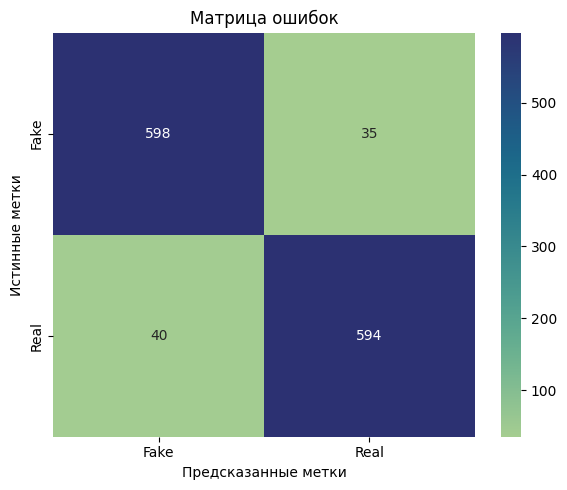

In [9]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='crest', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Матрица ошибок')
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

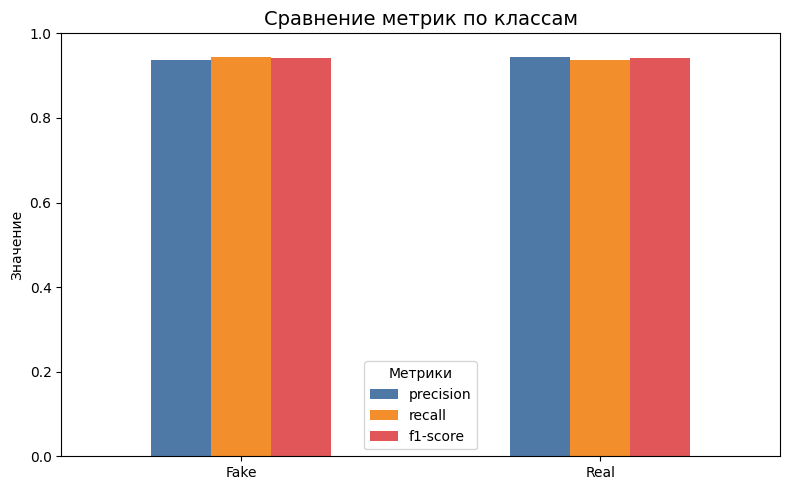

In [10]:
# Дополнительные метрики
metrics = ['precision', 'recall', 'f1-score']
df_report = pd.DataFrame(classification_report(y_test, y_pred, target_names=['Fake', 'Real'], output_dict=True)).T.iloc[:2, :]
df_for_plot = df_report[metrics]

df_for_plot.plot(kind='bar', figsize=(8, 5), color=['#4e79a7', '#f28e2b', '#e15759'])
plt.title("Сравнение метрик по классам", fontsize=14)
plt.ylabel("Значение")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Метрики")
plt.tight_layout()
plt.savefig('../reports/general_classification.png', dpi=150, bbox_inches='tight')
plt.show()

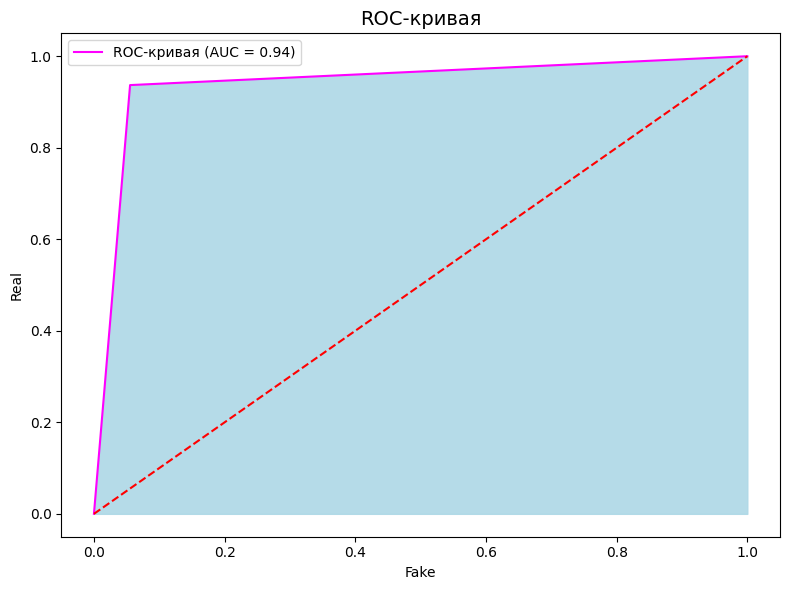

In [11]:
# ROC-кривая
fpr, tpr, tresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC-кривая (AUC = {roc_auc:.2f})", color='fuchsia')
plt.title("ROC-кривая", fontsize=14)
plt.plot([0 ,1], [0, 1], 'r--')
plt.fill_between(fpr, tpr, color='lightblue', alpha=0.9)
plt.ylabel('Real')
plt.xlabel('Fake')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

**Сохранение модели**

In [12]:
from src.config import MODEL_DIR


joblib.dump(model.model, MODEL_DIR / 'fake_news_model.pkl')
joblib.dump(model.vectorizer, MODEL_DIR / 'tfidf_vectorizer.pkl')

print("Модель и векторизатор успешно загружены в папку 'models/'")

Модель и векторизатор успешно загружены в папку 'models/'
